## Paper Title: Face Anti-Spoofing Using CNN Classifier and Face liveness Detection Implementation

### Implementation Summary  

This notebook contains the implementation of the core sequential anti-spoofing pipeline proposed in the paper, where a liveness verification stage is followed by CNN-based spoof classification.

#### What is implemented from the paper
    
The following main ideas of the paper are implemented:
- **Sequential 2-stage anti-spoofing workflow**
  - **Stage 1:** liveness verification (Liveliness Module)
  - **Stage 2:** CNN-based real vs fake face classification (CNN Classification Module)
- **Face anti-spoofing decision pipeline**
- **Real-time webcam-based testing workflow**
- **Binary classification of real and spoof faces**
- **Final decision based on combined liveness and CNN output**

This implementation preserves the main contribution of the paper: combining liveness detection with CNN classification in sequence.

#### Practical modification done in this implementation
The original paper describes liveness using:
- **eye blinking**
- **lip movement**
- **Android-based application deployment**

In this implementation, this part is implemented as a **practical desktop/Jupyter adaptation using webcam frame-to-frame facial motion detection**.

Instead of explicit blink and lip landmark tracking, the liveness stage uses:
- grayscale frame comparison
- motion thresholding
- multiple consecutive live frames validation

This modification was intentionally done to:
- make the system stable in Jupyter Notebook
- avoid Android-specific implementation dependency
- ensure reproducible live demonstration for mini-project presentation
- preserve the **same sequential liveness-first logic of the paper**

In [2]:
import os
import cv2
import time
import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications.resnet50 import preprocess_input

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:

dataset_root = '/Users/pranjalrathod/Documents/PRANJAL/SVNIT/YEARS/1ST YEAR/2ND SEMESTER/MINI PROJECT/PAPER 4/dataset/NUAA_READY'

train_dir = os.path.join(dataset_root, "train")
test_dir = os.path.join(dataset_root, "test")

IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 20

In [4]:
print("Dataset root exists:", os.path.exists(dataset_root))
print("Train dir exists   :", os.path.exists(train_dir))
print("Test dir exists    :", os.path.exists(test_dir))

Dataset root exists: True
Train dir exists   : True
Test dir exists    : True


In [5]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    validation_split=0.30,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1.0/255.0
)

In [6]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 2445 images belonging to 2 classes.
Found 1046 images belonging to 2 classes.
Found 9123 images belonging to 2 classes.
Class indices: {'fake': 0, 'real': 1}


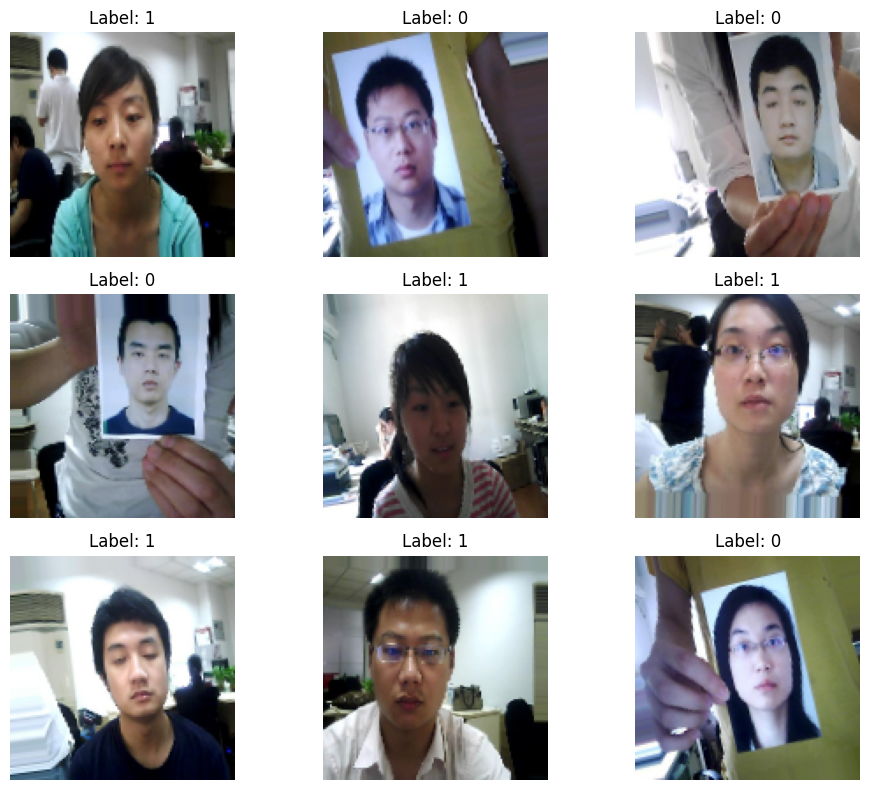

In [7]:
images, labels = next(train_generator)

plt.figure(figsize=(10, 8))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Label: {int(labels[i])}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [8]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,185 (24.86 MB)

 Trainable params: 6,516,737 (24.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        "best_cnn_spoof.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

In [10]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.9053 - loss: 1.1631
Epoch 1: val_accuracy improved from None to 0.50096, saving model to best_cnn_spoof.keras

Epoch 1: finished saving model to best_cnn_spoof.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 35s 424ms/step - accuracy: 0.9616 - loss: 0.5606 - val_accuracy: 0.5010 - val_loss: 41.0532 - learning_rate: 0.0010
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.9810 - loss: 0.3837
Epoch 2: val_accuracy did not improve from 0.50096
77/77 ━━━━━━━━━━━━━━━━━━━━ 32s 420ms/step - accuracy: 0.9824 - loss: 0.3206 - val_accuracy: 0.5010 - val_loss: 89.6782 - learning_rate: 0.0010
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.9906 - loss: 0.1361
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_accuracy did not improve from 0.50096
77/77 ━━━━━━━━━━━━━━━━━━━━ 34s 442ms/step - accuracy: 0.9910 - loss: 0.1355 - val_accuracy: 0.5010 - val_loss: 86.1231 - learning_r

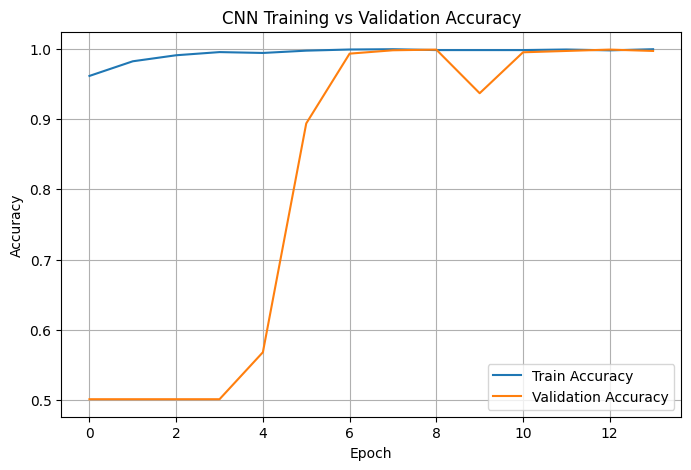

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

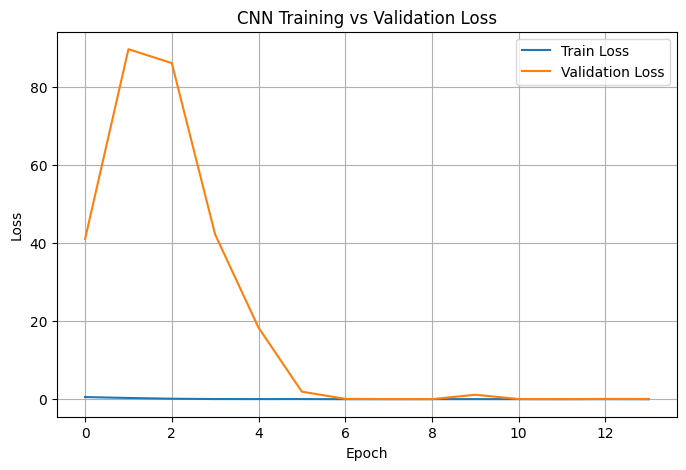

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print("Test Loss    :", test_loss)
print("Test Accuracy:", test_acc)

286/286 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - accuracy: 0.8190 - loss: 3.0442
Test Loss    : 3.0442054271698
Test Accuracy: 0.8190288543701172


In [14]:
y_prob = model.predict(test_generator)
y_pred = (y_prob > 0.5).astype(int).flatten()
y_true = test_generator.classes

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

286/286 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step
Accuracy : 0.8190288282363257
Precision: 0.6714085353636545
Recall   : 0.9967281380130875
F1 Score : 0.8023464623488566


In [15]:
class_names = list(test_generator.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        fake       1.00      0.72      0.83      5761
        real       0.67      1.00      0.80      3362

    accuracy                           0.82      9123
   macro avg       0.83      0.86      0.82      9123
weighted avg       0.88      0.82      0.82      9123



In [16]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[4121 1640]
 [  11 3351]]


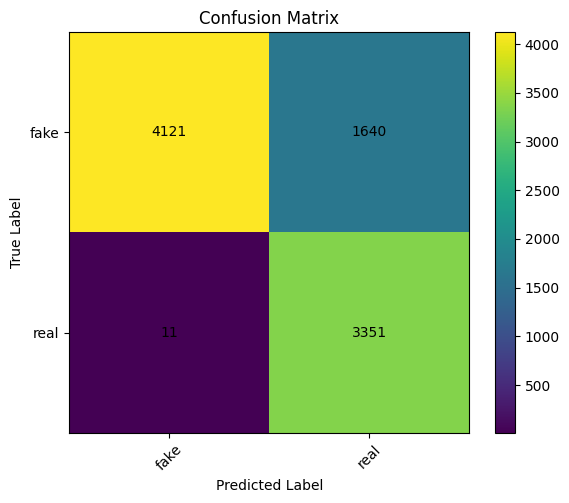

In [17]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

Real images found: 3362
Fake images found: 5761


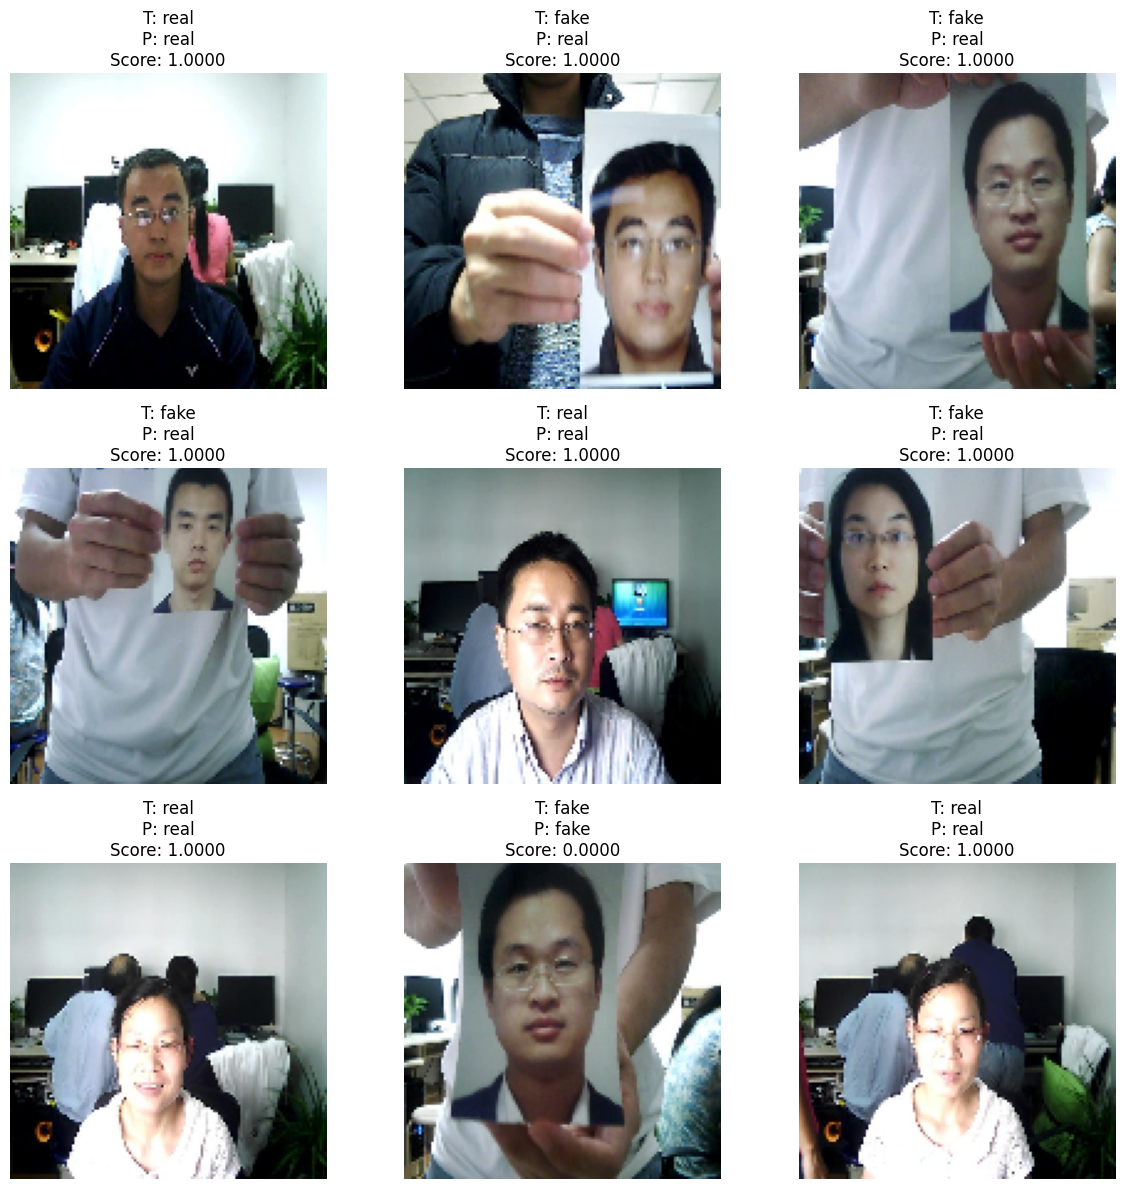

Correct predictions: 5/9
Accuracy on selected samples: 55.56%


In [21]:
real_folder = '/Users/pranjalrathod/Documents/PRANJAL/SVNIT/YEARS/1ST YEAR/2ND SEMESTER/MINI PROJECT/PAPER 4/dataset/NUAA_READY/test/real'
fake_folder = '/Users/pranjalrathod/Documents/PRANJAL/SVNIT/YEARS/1ST YEAR/2ND SEMESTER/MINI PROJECT/PAPER 4/dataset/NUAA_READY/test/fake'

num_real = 4
num_fake = 5

valid_ext = ('.jpg', '.jpeg', '.png', '.bmp')

real_files = [f for f in os.listdir(real_folder) if f.lower().endswith(valid_ext)]
fake_files = [f for f in os.listdir(fake_folder) if f.lower().endswith(valid_ext)]

print("Real images found:", len(real_files))
print("Fake images found:", len(fake_files))

num_real = min(num_real, len(real_files))
num_fake = min(num_fake, len(fake_files))

real_imgs = random.sample(real_files, num_real)
fake_imgs = random.sample(fake_files, num_fake)

test_samples = [(os.path.join(real_folder, x), "real") for x in real_imgs] + \
               [(os.path.join(fake_folder, x), "fake") for x in fake_imgs]

random.shuffle(test_samples)

plt.figure(figsize=(12, 12))
correct = 0
shown = 0

for i, (img_path, true_label) in enumerate(test_samples):
    try:
        img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)

        pred = model.predict(img_array, verbose=0)[0][0]
        predicted_label = "real" if pred > 0.5 else "fake"

        if predicted_label == true_label:
            correct += 1

        shown += 1
        plt.subplot(3, 3, shown)
        plt.imshow(load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE)))
        plt.title(f"T: {true_label}\nP: {predicted_label}\nScore: {pred:.4f}")
        plt.axis("off")

    except Exception as e:
        print(f"Error loading/predicting {img_path}: {e}")

plt.tight_layout()
plt.show()

total = len(test_samples)
print(f"Correct predictions: {correct}/{total}")
print(f"Accuracy on selected samples: {(correct/total)*100:.2f}%")

#### Liveliness Module

In [20]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

print("Face cascade loaded:", not face_cascade.empty())
print("Eye cascade loaded :", not eye_cascade.empty())

Face cascade loaded: True
Eye cascade loaded : True


In [37]:
cap = cv2.VideoCapture(0)

prev_face_gray = None
live_counter = 0
saved_path = "live_face.jpg"

MOTION_THRESHOLD = 8.0
REQUIRED_LIVE_FRAMES = 5
RUN_SECONDS = 15

start_time = time.time()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    final_status = "NO MOTION"

    for (x, y, w, h) in faces:
        face_roi_gray = gray[y:y+h, x:x+w]
        resized_face = cv2.resize(face_roi_gray, (100, 100))

        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)

        if prev_face_gray is not None:
            diff = cv2.absdiff(prev_face_gray, resized_face)
            motion_score = np.mean(diff)

            if motion_score > MOTION_THRESHOLD:
                live_counter += 1

            if live_counter >= REQUIRED_LIVE_FRAMES:
                final_status = "LIVE"
            else:
                final_status = "SPOOF"
        else:
            motion_score = 0.0

        prev_face_gray = resized_face.copy()

        cv2.putText(frame, f"Motion: {motion_score:.2f}", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
        break

    cv2.putText(frame, f"Stage 1: {final_status}", (20, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    cv2.imshow("OpenCV + CNN Anti-Spoofing", frame)

    # auto close after timer
    if time.time() - start_time > RUN_SECONDS:
        print("Auto closing camera after 15 seconds")
        break

    cv2.waitKey(1)

cap.release()
cv2.destroyAllWindows()

Auto closing camera after 15 seconds


In [38]:
def predict_face_image(img_path, model, img_size=128):
    img = load_img(img_path, target_size=(img_size, img_size))
    arr = img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    pred = model.predict(arr, verbose=0)[0][0]
    label = "real" if pred > 0.5 else "fake"
    return pred, label


In [39]:
pred, label = predict_face_image("live_face.jpg", model, IMG_SIZE)
print("Raw score:", pred)
print("Prediction:", label)

Raw score: 0.0
Prediction: fake


#### Liveliness Module + CNN Classifier Module Combined

In [40]:
cap = cv2.VideoCapture(0)

prev_face_gray = None
live_counter = 0
saved_path = "live_face.jpg"

MOTION_THRESHOLD = 8.0
REQUIRED_LIVE_FRAMES = 5
RUN_SECONDS = 10

start_time = time.time()
final_status = "NO FACE"

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    final_status = "NO FACE"

    for (x, y, w, h) in faces:
        face_roi_gray = gray[y:y+h, x:x+w]
        resized_face = cv2.resize(face_roi_gray, (100, 100))

        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)

        if prev_face_gray is not None:
            diff = cv2.absdiff(prev_face_gray, resized_face)
            motion_score = np.mean(diff)

            if motion_score > MOTION_THRESHOLD:
                live_counter += 1

            if live_counter >= REQUIRED_LIVE_FRAMES:
                final_status = "LIVE"
            else:
                final_status = "SPOOF"
        else:
            motion_score = 0.0

        prev_face_gray = resized_face.copy()

        cv2.putText(
            frame,
            f"Motion: {motion_score:.2f}",
            (x, y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 255),
            2
        )
        break

    cv2.putText(
        frame,
        f"Stage 1: {final_status}",
        (20, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

    cv2.imshow("OpenCV + CNN Anti-Spoofing", frame)

    if time.time() - start_time > RUN_SECONDS:
        cv2.imwrite(saved_path, frame)
        print("Image auto saved:", saved_path)
        print("Stage 1 result:", final_status)
        break

    cv2.waitKey(1)

cap.release()
cv2.destroyAllWindows()

if final_status == "LIVE":
    pred, label = predict_face_image(saved_path, model, IMG_SIZE)
    print("Stage 2 CNN result:", label)
    print("Raw score:", pred)
else:
    print("Stage 1 marked input as spoof. CNN stage skipped.")

Image auto saved: live_face.jpg
Stage 1 result: LIVE
Stage 2 CNN result: real
Raw score: 0.99999833
